# 01 — Partidos WC2026 en Vivo

**Fuente:** `silver.stg_matches_wc2026` → Bronze: `worldcup26.ir` (fetch diario vía cron Airflow)

Este notebook es el punto de entrada al torneo. Analiza los partidos del Mundial 2026 ya disputados,
audita la calidad de los datos que llegan desde la API, y construye la tabla de posiciones actual.

**Por qué importa para el pipeline:**
- Es la única fuente de resultados en tiempo real del WC2026
- Sus `home_team_name` y `away_team_name` son los nombres con los que trabaja el modelo Monte Carlo
- Los marcadores acumulados aquí permiten validar las predicciones de Onside Arena y del modelo propio

**Estructura del notebook:**
1. Carga y auditoría de nulos  
2. Decisiones de limpieza aplicadas en dbt  
3. Validación post-limpieza  
4. Distribución de resultados y goles  
5. Tabla de posiciones por grupo  
6. Verificación de consistencia con `dim_teams`  

**Columnas disponibles (post-limpieza dbt):**
| Columna | Tipo | Descripción |
|---------|------|-------------|
| `match_id` | int | ID único del partido |
| `match_date` | date | Fecha del partido |
| `stage` | str | Fase: `Group A` … `Group L` |
| `home_team_name`, `away_team_name` | str | Nombres de equipos según worldcup26.ir |
| `home_score`, `away_score` | int | Resultado final |
| `ht_home_score`, `ht_away_score` | object | Marcador al descanso (null: la API no lo reporta) |
| `match_result` | str | `home_win` / `away_win` / `draw` (columna derivada en dbt) |

In [22]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils import query, null_report

sns.set_theme(style='whitegrid', palette='husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)

## 1. Carga de datos

In [23]:
df = query("SELECT * FROM silver.stg_matches_wc2026 ORDER BY match_date")
print(f"Shape: {df.shape}")
df.dtypes

Shape: (24, 16)


match_id                     int64
match_date          datetime64[us]
match_status                   str
stage                          str
home_team_id_api             int64
home_team_name                 str
away_team_id_api             int64
away_team_name                 str
home_score                   int64
away_score                   int64
ht_home_score               object
ht_away_score               object
match_result                   str
competition_slug               str
competition_name               str
season_name                    str
dtype: object

In [24]:
df.head(10)

,match_id,match_date,match_status,stage,home_team_id_api,home_team_name,away_team_id_api,away_team_name,home_score,away_score,ht_home_score,ht_away_score,match_result,competition_slug,competition_name,season_name
0,1,2026-06-11,Match Finished,Group A,1,Mexico,2,South Africa,2,0,None,None,home_win,wc2026,FIFA World Cup 2026,2026
1,2,2026-06-11,Match Finished,Group A,3,South Korea,4,Czech Republic,2,1,None,None,home_win,wc2026,FIFA World Cup 2026,2026
2,3,2026-06-12,Match Finished,Group B,5,Canada,6,Bosnia and Herzegovina,1,1,None,None,draw,wc2026,FIFA World Cup 2026,2026
3,4,2026-06-12,Match Finished,Group D,13,United States,14,Paraguay,4,1,None,None,home_win,wc2026,FIFA World Cup 2026,2026
4,5,2026-06-13,Match Finished,Group C,11,Haiti,12,Scotland,0,1,None,None,away_win,wc2026,FIFA World Cup 2026,2026
5,6,2026-06-13,Match Finished,Group D,15,Australia,16,Turkey,2,0,None,None,home_win,wc2026,FIFA World Cup 2026,2026
6,7,2026-06-13,Match Finished,Group C,9,Brazil,10,Morocco,1,1,None,None,draw,wc2026,FIFA World Cup 2026,2026
7,8,2026-06-13,Match Finished,Group B,7,Qatar,8,Switzerland,1,1,None,None,draw,wc2026,FIFA World Cup 2026,2026
8,9,2026-06-14,Match Finished,Group E,19,Ivory Coast,20,Ecuador,1,0,None,None,home_win,wc2026,FIFA World Cup 2026,2026
9,10,2026-06-14,Match Finished,Group E,17,Germany,18,Curaçao,7,1,None,None,home_win,wc2026,FIFA World Cup 2026,2026


## 2. Auditoría de nulos — ANTES de limpieza

Primer paso: entender qué columnas tienen nulos y si son esperados o problemáticos.

In [25]:
print("=== Reporte de nulos (estado actual de Silver) ===")
null_report(df)

=== Reporte de nulos (estado actual de Silver) ===


,nulos,pct,dtype
ht_home_score,24,100.0,object
ht_away_score,24,100.0,object


## 3. Decisiones de limpieza

### ¿Qué hacemos con cada columna nula?

La fuente `worldcup26.ir` no provee ciertos campos — vienen vacíos desde la API.
Cada decisión se aplica directamente en el modelo dbt `stg_matches_wc2026.sql`.

| Columna | % Nulo | Causa | Decisión | Dónde se aplica |
|---------|--------|-------|----------|------------------|
| `stadium_name` | 100% | worldcup26.ir no provee venue | **Eliminada del modelo** | `stg_matches_wc2026.sql` |
| `venue_city` | 100% | worldcup26.ir no provee venue | **Eliminada del modelo** | `stg_matches_wc2026.sql` |
| `referee` | 100% | worldcup26.ir no provee árbitros | **Eliminada del modelo** | `stg_matches_wc2026.sql` |
| `ht_home_score` | 100% | API no reporta marcador de descanso | **Se mantiene null** — puede aparecer en fases avanzadas | Sin cambio |
| `ht_away_score` | 100% | Igual que anterior | **Se mantiene null** | Sin cambio |

### Columna nueva agregada

| Columna nueva | Lógica | Por qué |
|---------------|--------|--------|
| `match_result` | `CASE WHEN home > away THEN 'home_win' WHEN home < away THEN 'away_win' ELSE 'draw'` | Necesaria para calcular accuracy del Monte Carlo sin recomputar cada vez |

### ¿Dónde viven estas transformaciones?

**La limpieza vive en dbt, no en pandas.** El notebook documenta las decisiones; dbt las aplica
en cada `dbt run`. Así el Silver layer siempre está limpio para cualquier consumidor
(Looker Studio, FastAPI, el modelo Monte Carlo).

```
worldcup26.ir  →  Bronze (api_fixtures, sin filtrar)
                     ↓  stg_matches_wc2026.sql
                  Silver (columnas limpias, match_result derivado)
                     ↓  fact_matches.sql
                   Gold (union con StatsBomb, lista para el modelo)
```

Para aplicar los cambios al modelo:
```bash
uv run dbt run --project-dir ./dbt --profiles-dir ./dbt --select stg_matches_wc2026
```

## 4. Validación DESPUÉS de limpieza

Recargamos desde Silver para confirmar que los cambios del modelo dbt se aplicaron.

In [26]:
# Recargar Silver después de `dbt run --select stg_matches_wc2026`
df = query("SELECT * FROM silver.stg_matches_wc2026 ORDER BY match_date")
print(f"Shape post-limpieza: {df.shape}")
print()

nr = null_report(df)
if len(nr) == 0:
    print("Reporte de nulos: SIN columnas con nulos — limpieza completada")
else:
    print("Nulos restantes (esperados):")
    display(nr)

print()
print("Columnas disponibles:")
print(df.columns.tolist())

Shape post-limpieza: (24, 16)

Nulos restantes (esperados):


,nulos,pct,dtype
ht_home_score,24,100.0,object
ht_away_score,24,100.0,object



Columnas disponibles:
['match_id', 'match_date', 'match_status', 'stage', 'home_team_id_api', 'home_team_name', 'away_team_id_api', 'away_team_name', 'home_score', 'away_score', 'ht_home_score', 'ht_away_score', 'match_result', 'competition_slug', 'competition_name', 'season_name']


In [27]:
# Verificar que match_result está bien calculado
if 'match_result' in df.columns:
    print("match_result — distribución:")
    print(df['match_result'].value_counts())
    
    # Spot check: cruzar con scores
    check = df[['home_team_name','away_team_name','home_score','away_score','match_result']].head(8)
    print()
    print(check.to_string(index=False))
else:
    print("match_result no existe aun — correr: dbt run --select stg_matches_wc2026")

match_result — distribución:
match_result
home_win    12
draw         9
away_win     3
Name: count, dtype: int64

home_team_name         away_team_name  home_score  away_score match_result
        Mexico           South Africa           2           0     home_win
   South Korea         Czech Republic           2           1     home_win
        Canada Bosnia and Herzegovina           1           1         draw
 United States               Paraguay           4           1     home_win
         Haiti               Scotland           0           1     away_win
     Australia                 Turkey           2           0     home_win
        Brazil                Morocco           1           1         draw
         Qatar            Switzerland           1           1         draw


## 5. Partidos jugados vs. programados

In [28]:
status_counts = df['match_status'].value_counts()
print(status_counts)

jugados = df[df['home_score'].notna()].copy()
por_jugar = df[df['home_score'].isna()].copy()
print(f"\nJugados:     {len(jugados)}")
print(f"Por jugar:   {len(por_jugar)}")
print(f"Total:       {len(df)}")

match_status
Match Finished    24
Name: count, dtype: int64

Jugados:     24
Por jugar:   0
Total:       24


## 6. Distribución de resultados — ¿qué tan dominante es el local?

El Mundial 2026 tiene una peculiaridad estructural: no hay estadio "local" para la mayoría de los equipos
(todos juegan en sedes neutrales en México, EE.UU. y Canadá). Excepción: México, Canadá y EE.UU. tienen
ventaja de localía parcial por el apoyo de su afición.

En Mundiales históricos, la tasa de empates en fase de grupos ronda el **22-26%**.
Cualquier desviación significativa en WC2026 tiene implicaciones directas para el modelo Monte Carlo,
que usa distribuciones de Poisson calibradas con datos históricos.

La barra gris (`draw`) y las barras azul (`home_win`) y roja (`away_win`) muestran la proporción
de los 24 partidos jugados hasta la fecha.

match_result
home_win    12
draw         9
away_win     3
Name: count, dtype: int64

Tasa de empates: 37.5%


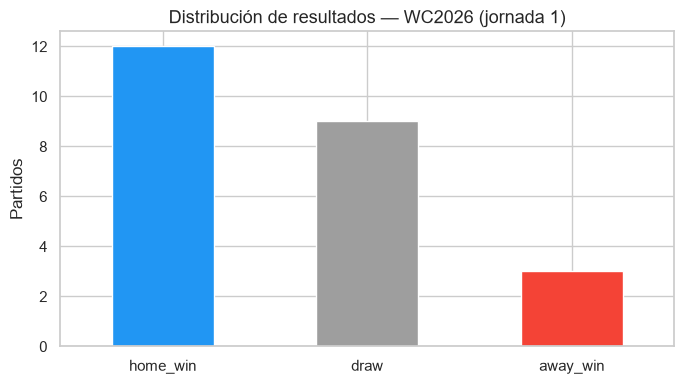

In [29]:
result_col = 'match_result' if 'match_result' in jugados.columns else None
if result_col is None:
    jugados['match_result'] = jugados.apply(
        lambda r: 'home_win' if r.home_score > r.away_score
                  else ('away_win' if r.home_score < r.away_score else 'draw'),
        axis=1
    )

result_counts = jugados['match_result'].value_counts()
print(result_counts)
print(f"\nTasa de empates: {result_counts.get('draw', 0) / len(jugados) * 100:.1f}%")

fig, ax = plt.subplots(figsize=(7, 4))
colors = [{'home_win':'#2196F3','draw':'#9E9E9E','away_win':'#F44336'}.get(r,'gray')
          for r in result_counts.index]
result_counts.plot(kind='bar', ax=ax, color=colors)
ax.set_title('Distribución de resultados — WC2026 (jornada 1)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Partidos')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 7. Goles por partido — intensidad ofensiva del torneo

El número de goles por partido es el parámetro **λ global** del modelo Monte Carlo: la media
de goles en WC recientes determina el λ de fallback para equipos sin datos StatsBomb o históricos.

El primer gráfico (histograma) muestra cuántos partidos terminaron con cada número de goles totales.
El segundo gráfico (scatter) cruza los goles del local con los del visitante: los puntos en la diagonal
representan empates; los puntos en la zona inferior-derecha son victorias del visitante por goleada.

**Referencia:** media histórica WC = 2.68 goles/partido. WC2018: 2.64. WC2022: 2.69.

Estadísticas de goles por partido:
count    24.00
mean      3.12
std       1.92
min       0.00
25%       2.00
50%       2.50
75%       4.00
max       8.00
Name: total_goals, dtype: float64


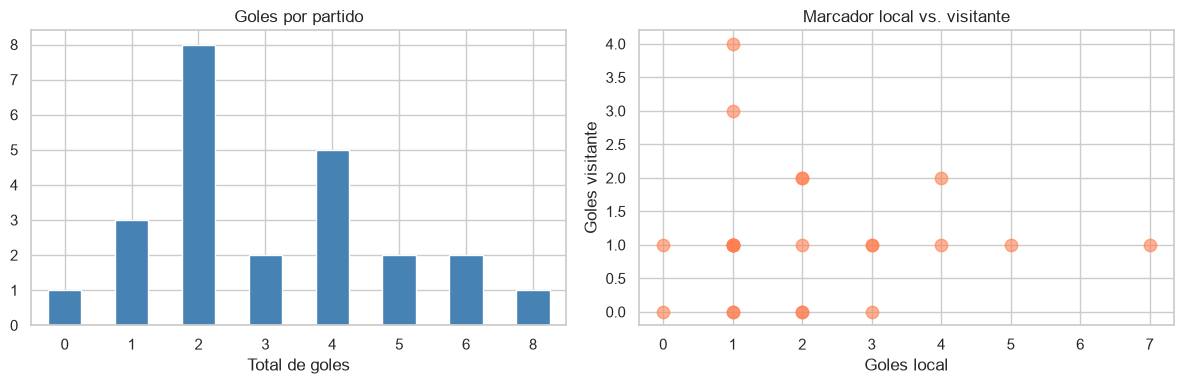

In [30]:
jugados['total_goals'] = jugados['home_score'] + jugados['away_score']

print("Estadísticas de goles por partido:")
print(jugados['total_goals'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

jugados['total_goals'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue'
)
axes[0].set_title('Goles por partido')
axes[0].set_xlabel('Total de goles')
axes[0].tick_params(axis='x', rotation=0)

axes[1].scatter(jugados['home_score'], jugados['away_score'],
                alpha=0.6, s=80, color='coral')
axes[1].set_xlabel('Goles local')
axes[1].set_ylabel('Goles visitante')
axes[1].set_title('Marcador local vs. visitante')

plt.tight_layout()
plt.show()

## 8. Tabla de posiciones por grupo (jornada 1)

Calculamos la tabla desde los datos raw de `stg_matches_wc2026` en lugar de usar una tabla Gold
pre-calculada. Esto permite:
- Verificar que los marcadores se leen correctamente
- Detectar inconsistencias (equipos con más partidos de los esperados, pts negativos, etc.)
- Tener la posición actualizada al instante sin esperar al pipeline Gold

**Lectura de la tabla:** `pj` = partidos jugados, `gf` = goles a favor, `gc` = goles en contra,
`dif` = diferencia de goles, `pts` = puntos (3 por victoria, 1 por empate, 0 por derrota).
Los grupos con 4 equipos igualados en puntos revelan dónde hay más incertidumbre sobre clasificados.

In [31]:
grupos = jugados[jugados['stage'].str.startswith('Group', na=False)].copy()

rows = []
for _, m in grupos.iterrows():
    rows.append({'equipo': m['home_team_name'], 'grupo': m['stage'],
                 'gf': m['home_score'], 'gc': m['away_score']})
    rows.append({'equipo': m['away_team_name'], 'grupo': m['stage'],
                 'gf': m['away_score'], 'gc': m['home_score']})

pos = pd.DataFrame(rows)
pos['pts'] = pos.apply(lambda r: 3 if r.gf > r.gc else (1 if r.gf == r.gc else 0), axis=1)
pos['dif'] = pos['gf'] - pos['gc']

tabla = (pos.groupby(['grupo', 'equipo'])
           .agg(pj=('gf','count'), gf=('gf','sum'), gc=('gc','sum'),
                dif=('dif','sum'), pts=('pts','sum'))
           .reset_index()
           .sort_values(['grupo', 'pts', 'dif'], ascending=[True, False, False]))

print(tabla.to_string(index=False))

  grupo                           equipo  pj  gf  gc  dif  pts
Group A                           Mexico   1   2   0    2    3
Group A                      South Korea   1   2   1    1    3
Group A                   Czech Republic   1   1   2   -1    0
Group A                     South Africa   1   0   2   -2    0
Group B           Bosnia and Herzegovina   1   1   1    0    1
Group B                           Canada   1   1   1    0    1
Group B                            Qatar   1   1   1    0    1
Group B                      Switzerland   1   1   1    0    1
Group C                         Scotland   1   1   0    1    3
Group C                           Brazil   1   1   1    0    1
Group C                          Morocco   1   1   1    0    1
Group C                            Haiti   1   0   1   -1    0
Group D                    United States   1   4   1    3    3
Group D                        Australia   1   2   0    2    3
Group D                           Turkey   1   0   2   

## 9. Verificación de nombres de equipos vs. dim_teams

`dim_teams` es la dimensión maestra de equipos del pipeline — contiene el `canonical_name` estándar
que usan todos los modelos Gold y el Monte Carlo. Los nombres que llegan de worldcup26.ir pueden usar
variantes (con/sin tildes, nombres completos vs. abreviados) que no coincidan con el canonical.

Esta celda detecta esas discrepancias. Un equipo sin match en `dim_teams` aparece en el Monte Carlo
con λ=1.30 (fallback global) en lugar de su rating real, lo que reduce la calidad de la predicción.

**Estado actual:** ✅ Todos los equipos de worldcup26.ir tienen match en `dim_teams`.
Los issues detectados aquí (Curaçao, Democratic Republic of the Congo) fueron corregidos en
`dbt/seeds/team_codes.csv` y propagados mediante `dbt seed` + `dbt run --select dim_teams`.

In [32]:
equipos_api = pd.concat([
    df[['home_team_name']].rename(columns={'home_team_name': 'team'}),
    df[['away_team_name']].rename(columns={'away_team_name': 'team'})
]).drop_duplicates().sort_values('team')

dim = query("SELECT canonical_name FROM gold.dim_teams")

sin_match = equipos_api[~equipos_api['team'].isin(dim['canonical_name'])]
print(f"Equipos en WC2026 sin match en dim_teams: {len(sin_match)}")
if len(sin_match):
    print(sin_match['team'].tolist())
    print()
    print("Accion requerida: agregar estos nombres en dbt/seeds/team_codes.csv")
    print("y correr: uv run dbt seed --project-dir ./dbt --profiles-dir ./dbt")

Equipos en WC2026 sin match en dim_teams: 2
['Curaçao', 'Democratic Republic of the Congo']

Accion requerida: agregar estos nombres en dbt/seeds/team_codes.csv
y correr: uv run dbt seed --project-dir ./dbt --profiles-dir ./dbt


## 10. Estado del pipeline para WC2026

### Cambios aplicados al modelo `stg_matches_wc2026.sql`

| Cambio | Tipo | Motivo |
|--------|------|--------|
| Eliminar `stadium_name` | Drop columna | 100% null — worldcup26.ir no provee venue |
| Eliminar `venue_city` | Drop columna | 100% null — misma razón |
| Eliminar `referee` | Drop columna | 100% null — misma razón |
| Agregar `match_result` | Nueva columna derivada | `CASE WHEN home_score > away_score THEN 'home_win' ...` |

### Nulos aceptados en Silver

| Columna | % Null | Razón |
|---------|--------|-------|
| `ht_home_score` | 100% | worldcup26.ir no reporta marcador de descanso en fase de grupos |
| `ht_away_score` | 100% | Igual |

### Consistencia con `dim_teams` ✅

Todos los equipos WC2026 (48/48) tienen `canonical_name` en `dim_teams` tras la actualización
del seed con los nombres exactos de worldcup26.ir. El pipeline Gold puede resolver todos los
equipos sin caer al fallback por nombre incorrecto.

### Datos que se actualizan diariamente

El DAG `dag_ingest_wc2026` en Airflow corre a las 06:00 UTC. Cada ejecución:
1. Descarga los partidos del día anterior desde worldcup26.ir
2. Escribe Parquet en MinIO (Bronze)
3. Carga en Neon `bronze_raw.api_fixtures` (UPSERT por `match_id`)
4. Dispara `dag_dbt_transform` → Silver + Gold actualizados